# Provider-Level Anamoly/Fraud Detection

In [37]:
# Imports       

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
# Upload Datasets

ip = pd.read_csv('Train_IP.csv')
op = pd.read_csv('Train_OP.csv')
beneficiary = pd.read_csv('Train_Beneficiary.csv')
train = pd.read_csv('Train.csv')


In [4]:
# Combining Inpatient and Outpatient Claims

op['claim_type'] = 0
ip['claim_type'] = 1

claims = pd.concat([ip, op], axis=0, ignore_index=True)
claims.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,claim_type
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1


In [5]:
# Adding Patient Data to Claims Table

claims = pd.merge(claims, beneficiary, on='BeneID', how='left')
claims.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,1,1,2,1,1,36000,3204,60,70
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,1,1,2,1,1,36000,3204,60,70
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,1,1,2,2,1,1,5000,1068,250,320
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,1,2,1,2,2,2,21260,2136,120,100


In [7]:
# Feature Engineering for Each Provider and Creating a Provider-Level Dataset

provider = pd.DataFrame()

provider['total_claims'] = claims.groupby('Provider').size()
provider['unique_patients'] = claims.groupby('Provider')['BeneID'].nunique()
provider['claims_per_patient'] = provider['total_claims'] / provider['unique_patients']

provider['total_reimbursement'] = claims.groupby('Provider')['InscClaimAmtReimbursed'].sum()
provider['avg_reimbursement'] = claims.groupby('Provider')['InscClaimAmtReimbursed'].mean()
provider['std_reimbursement'] = claims.groupby('Provider')['InscClaimAmtReimbursed'].std()
provider['max_reimbursement'] = claims.groupby('Provider')['InscClaimAmtReimbursed'].max()

provider['total_deductible_paid'] = claims.groupby('Provider')['DeductibleAmtPaid'].sum()
provider['avg_deductible_paid'] = claims.groupby('Provider')['DeductibleAmtPaid'].mean()

provider['pct_inpatient_claims'] = claims.groupby('Provider')['claim_type'].mean()  # 1 for inpatient, 0 for outpatient

ip['length_of_stay'] = (pd.to_datetime(ip['DischargeDt']) - pd.to_datetime(ip['AdmissionDt'])).dt.days
provider['avg_length_of_stay'] = ip.groupby('Provider')['length_of_stay'].mean()

provider['total_stay_days'] = (
    (pd.to_datetime(ip['DischargeDt']) -
     pd.to_datetime(ip['AdmissionDt']))
    .dt.days
    .groupby(ip['Provider'])
    .sum()
)

provider['num_unique_attending_physicians'] = claims.groupby('Provider')['AttendingPhysician'].nunique()
provider['num_unique_operating_physicians'] = claims.groupby('Provider')['OperatingPhysician'].nunique()
provider['num_unique_other_physicians'] = claims.groupby('Provider')['OtherPhysician'].nunique()

diag_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]
# melt all 10 diagnosis columns into one long column, alongside Provider
diag_long = claims.melt(
    id_vars='Provider',
    value_vars=diag_cols,
    value_name='diagnosis_code'
).dropna(subset=['diagnosis_code'])

provider['num_unique_diagnosis_codes'] = diag_long.groupby('Provider')['diagnosis_code'].nunique()

proc_cols = [f'ClmProcedureCode_{i}' for i in range(1, 7)]
proc_long = claims.melt(
    id_vars='Provider',
    value_vars=proc_cols,
    value_name='procedure_code'
).dropna(subset=['procedure_code'])

provider['num_unique_procedure_codes'] = proc_long.groupby('Provider')['procedure_code'].nunique()

# count non-null diagnosis codes per row (per claim)
claims['num_diag_codes_this_claim'] = claims[diag_cols].notna().sum(axis=1)

# average that per provider
provider['avg_num_diagnosis_codes_per_claim'] = claims.groupby('Provider')['num_diag_codes_this_claim'].mean()

# count non-null procedure codes per row (per claim)
claims['num_proc_codes_this_claim'] = claims[proc_cols].notna().sum(axis=1)

# average that per provider
provider['avg_num_procedure_codes_per_claim'] = claims.groupby('Provider')['num_proc_codes_this_claim'].mean()

provider['avg_claim_duration'] = (
    (pd.to_datetime(claims['ClaimEndDt']) - pd.to_datetime(claims['ClaimStartDt']))
    .dt.days
    .groupby(claims['Provider'])
    .mean()
)

provider['avg_patient_age'] = (
    (pd.to_datetime(claims['ClaimEndDt']) - pd.to_datetime(claims['DOB'])).dt.days / 365.25
).groupby(claims['Provider']).mean()

patient_level = claims.drop_duplicates(subset=['Provider', 'BeneID'])
provider['pct_patients_deceased'] = patient_level.groupby('Provider')['DOD'].apply(lambda x: x.notna().mean())
provider['avg_patient_IPAnnualReimbursement'] = patient_level.groupby('Provider')['IPAnnualReimbursementAmt'].mean()
provider['avg_patient_OPAnnualReimbursement'] = patient_level.groupby('Provider')['OPAnnualReimbursementAmt'].mean()

provider['reimbursement_per_diagnosis_code'] = provider['total_reimbursement'] / provider['num_unique_diagnosis_codes']

phys_long = claims.melt(
    id_vars='Provider',
    value_vars=['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician'],
    value_name='physician_id'
).dropna(subset=['physician_id'])
provider['num_unique_physicians'] = phys_long.groupby('Provider')['physician_id'].nunique()
provider['claims_to_physician_ratio'] = provider['total_claims'] / provider['num_unique_physicians']


provider

,total_claims,unique_patients,claims_per_patient,total_reimbursement,avg_reimbursement,std_reimbursement,max_reimbursement,total_deductible_paid,avg_deductible_paid,pct_inpatient_claims,...,avg_num_diagnosis_codes_per_claim,avg_num_procedure_codes_per_claim,avg_claim_duration,avg_patient_age,pct_patients_deceased,avg_patient_IPAnnualReimbursement,avg_patient_OPAnnualReimbursement,reimbursement_per_diagnosis_code,num_unique_physicians,claims_to_physician_ratio
Provider,,,,,,,,,,,,,,,,,,,,,
PRV51001,25,24,1.041667,104640,4185.600000,10796.091144,42000,5340.0,213.600000,0.200000,...,3.200000,0.120000,1.440000,78.213388,0.000000,18047.916667,2537.500000,1453.333333,19,1.315789
PRV51003,132,117,1.128205,605670,4588.409091,7309.794729,57000,66286.0,502.166667,0.469697,...,5.250000,0.363636,3.674242,69.549852,0.008547,6814.017094,2490.598291,1659.369863,51,2.588235
PRV51004,149,138,1.079710,52170,350.134228,689.963754,3300,310.0,2.080537,0.000000,...,2.583893,0.000000,1.429530,71.742348,0.007246,4596.739130,2095.144928,195.393258,48,3.104167
PRV51005,1165,495,2.353535,280910,241.124464,491.556392,4080,3700.0,3.175966,0.000000,...,2.588841,0.000000,1.088412,70.030263,0.006061,3717.232323,1798.808081,217.086553,7,166.428571
PRV51007,72,58,1.241379,33710,468.194444,1433.769116,10000,3264.0,45.333333,0.041667,...,2.986111,0.013889,0.958333,68.792798,0.017241,3109.655172,1497.241379,204.303030,11,6.545455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PRV57759,28,24,1.166667,10640,380.000000,820.880286,3300,130.0,4.642857,0.000000,...,2.071429,0.000000,2.142857,73.431994,0.000000,3414.166667,2910.416667,217.142857,1,28.000000
PRV57760,22,9,2.444444,4770,216.818182,309.998254,1100,0.0,0.000000,0.000000,...,2.363636,0.000000,0.318182,60.975546,0.000000,1240.000000,1883.333333,101.489362,3,7.333333
PRV57761,82,67,1.223881,18470,225.243902,418.366092,2200,370.0,4.512195,0.000000,...,2.670732,0.000000,1.390244,71.500142,0.014925,6737.313433,2506.716418,101.483516,7,11.714286


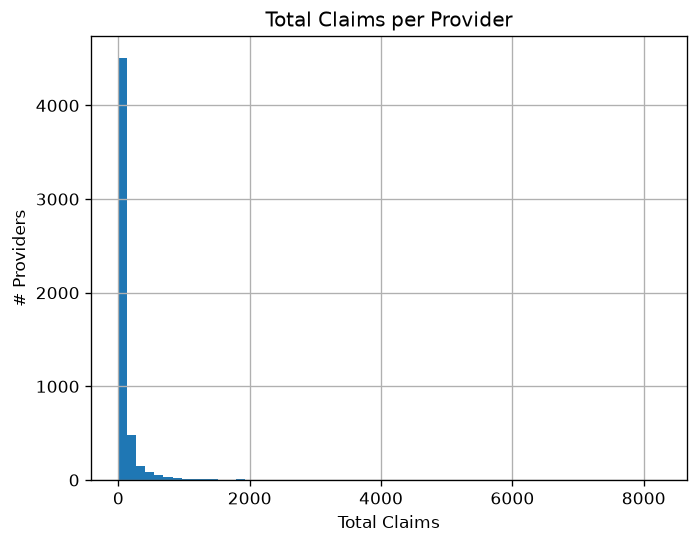

In [19]:
provider['total_claims'].hist(bins=60)
plt.title('Total Claims per Provider')
plt.xlabel('Total Claims'); plt.ylabel('# Providers')
plt.show()

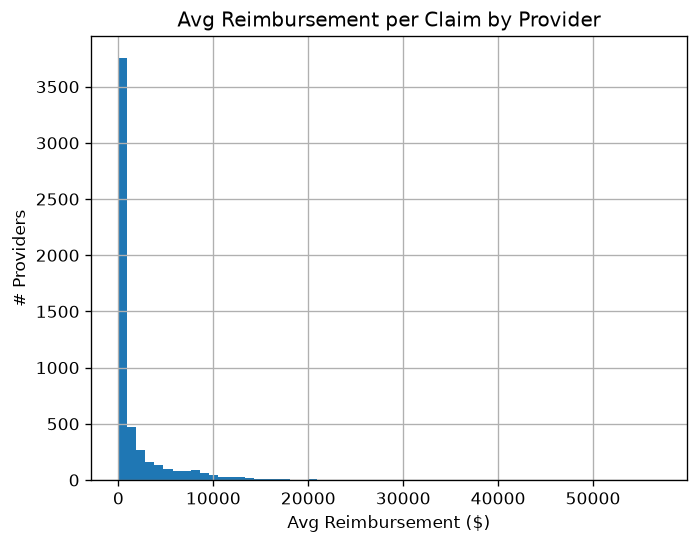

In [20]:
provider['avg_reimbursement'].hist(bins=60)
plt.title('Avg Reimbursement per Claim by Provider')
plt.xlabel('Avg Reimbursement ($)'); plt.ylabel('# Providers')
plt.show()

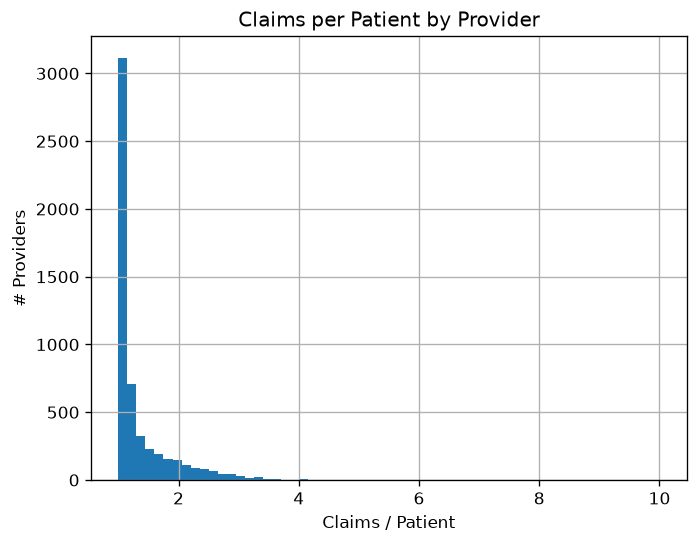

In [21]:
provider['claims_per_patient'].hist(bins=60)
plt.title('Claims per Patient by Provider')
plt.xlabel('Claims / Patient'); plt.ylabel('# Providers')
plt.show()

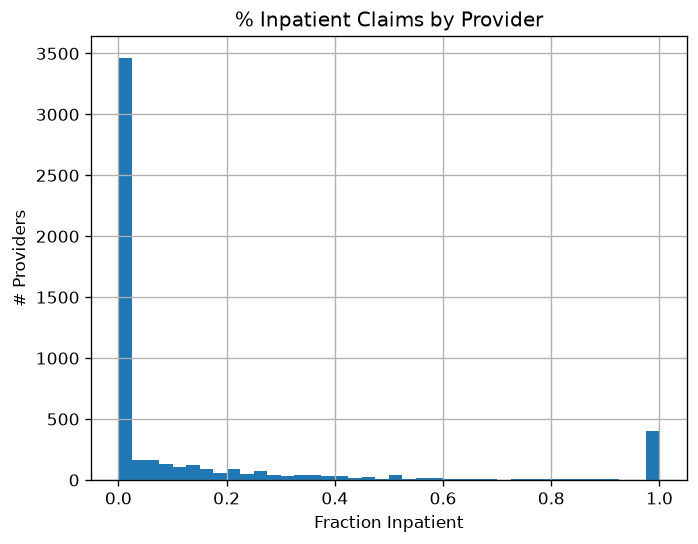

In [22]:
provider['pct_inpatient_claims'].hist(bins=40)
plt.title('% Inpatient Claims by Provider')
plt.xlabel('Fraction Inpatient'); plt.ylabel('# Providers')
plt.show()

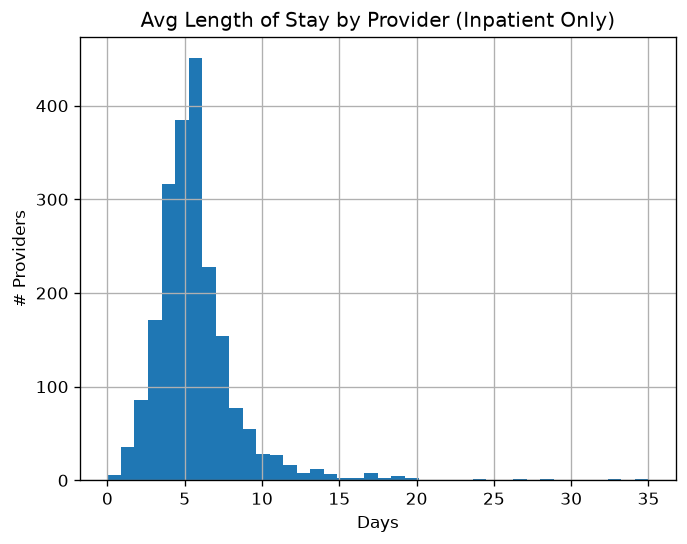

In [23]:
provider['avg_length_of_stay'].dropna().hist(bins=40)
plt.title('Avg Length of Stay by Provider (Inpatient Only)')
plt.xlabel('Days'); plt.ylabel('# Providers')
plt.show()

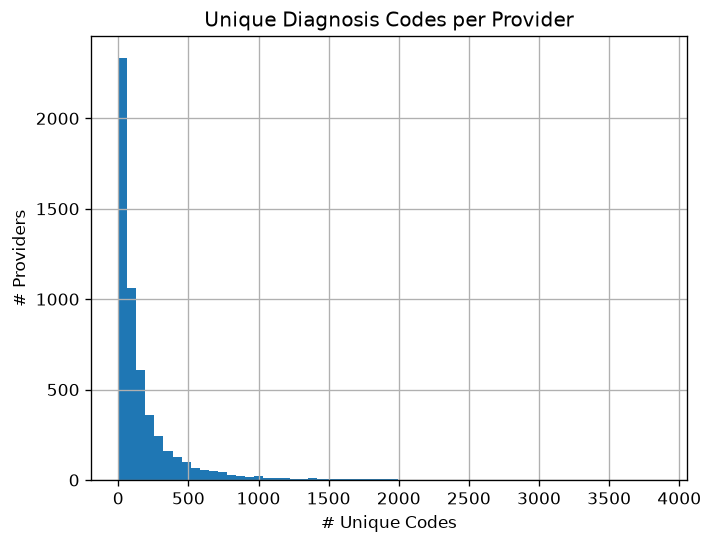

In [24]:
provider['num_unique_diagnosis_codes'].hist(bins=60)
plt.title('Unique Diagnosis Codes per Provider')
plt.xlabel('# Unique Codes'); plt.ylabel('# Providers')
plt.show()

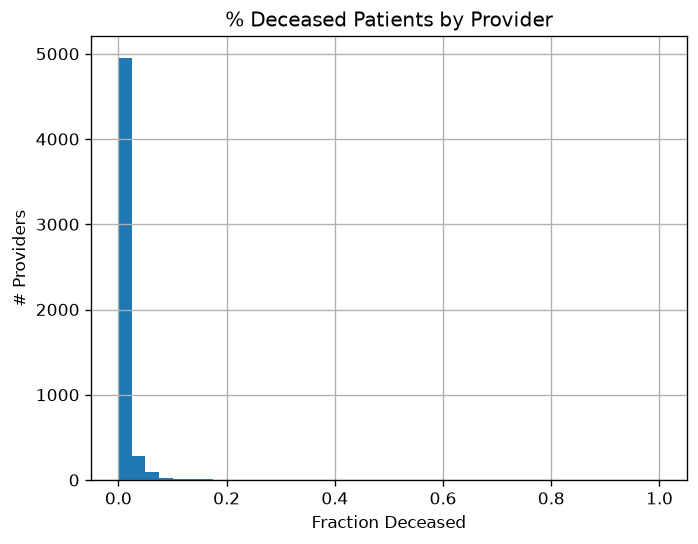

In [25]:
provider['pct_patients_deceased'].hist(bins=40)
plt.title('% Deceased Patients by Provider')
plt.xlabel('Fraction Deceased'); plt.ylabel('# Providers')
plt.show()

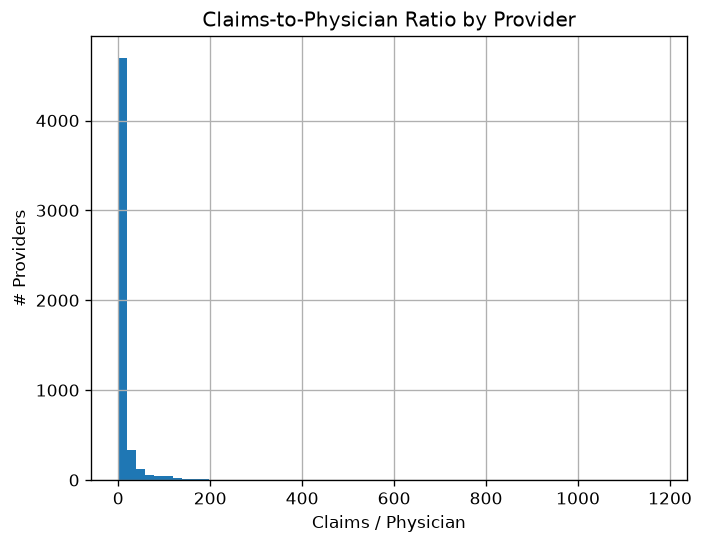

In [26]:
provider['claims_to_physician_ratio'].hist(bins=60)
plt.title('Claims-to-Physician Ratio by Provider')
plt.xlabel('Claims / Physician'); plt.ylabel('# Providers')
plt.show()

In [ ]:
# Creating Provider-Level Dataset with Target Variable for Supervised Learning

provider_with_target = pd.merge(provider, train, on='Provider', how='left')

provider_with_target['PotentialFraud'] = provider_with_target['PotentialFraud'].map({'Yes': 1, 'No': 0})

provider_with_target.head()

,Provider,total_claims,unique_patients,claims_per_patient,total_reimbursement,avg_reimbursement,std_reimbursement,max_reimbursement,total_deductible_paid,avg_deductible_paid,...,avg_num_procedure_codes_per_claim,avg_claim_duration,avg_patient_age,pct_patients_deceased,avg_patient_IPAnnualReimbursement,avg_patient_OPAnnualReimbursement,reimbursement_per_diagnosis_code,num_unique_physicians,claims_to_physician_ratio,PotentialFraud
0,PRV51001,25,24,1.041667,104640,4185.600000,10796.091144,42000,5340.0,213.600000,...,0.120000,1.440000,78.213388,0.000000,18047.916667,2537.500000,1453.333333,19,1.315789,0
1,PRV51003,132,117,1.128205,605670,4588.409091,7309.794729,57000,66286.0,502.166667,...,0.363636,3.674242,69.549852,0.008547,6814.017094,2490.598291,1659.369863,51,2.588235,1
2,PRV51004,149,138,1.079710,52170,350.134228,689.963754,3300,310.0,2.080537,...,0.000000,1.429530,71.742348,0.007246,4596.739130,2095.144928,195.393258,48,3.104167,0
3,PRV51005,1165,495,2.353535,280910,241.124464,491.556392,4080,3700.0,3.175966,...,0.000000,1.088412,70.030263,0.006061,3717.232323,1798.808081,217.086553,7,166.428571,1
4,PRV51007,72,58,1.241379,33710,468.194444,1433.769116,10000,3264.0,45.333333,...,0.013889,0.958333,68.792798,0.017241,3109.655172,1497.241379,204.303030,11,6.545455,0


In [39]:
X = provider_with_target.drop(columns=['PotentialFraud'])
y = provider_with_target['PotentialFraud']

# 70% train, 15% val, 15% test — all stratified on fraud label
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 3787 | Val: 811 | Test: 812
